# Deep Learning Models (LOIO-CV Test)
## 训练后模型测试与留一交叉验证评估
本代码用于加载已训练好的深度学习模型（如 DCL、DCLSA 等），在留一个体交叉验证的测试集上评估分类性能。它自动遍历每个个体，加载对应最佳模型权重，计算准确率、混淆矩阵、各类别 F1 分数等指标，并汇总所有个体的测试结果，最终生成宏平均和加权平均性能表。该实现对应论文第 2.3 节评估方法与第 3 节实验对比，用于复现图 6、图 7 及附表 S10–S11 中的模型性能结果。

# Import Modules

In [13]:
# =============================================================================
# 导入标准库
# os：文件和目录操作
# glob：文件路径匹配（用于批量查找模型权重文件）
# pandas：数据处理（读取和保存 CSV 结果）
# matplotlib.pyplot：绘图（混淆矩阵、性能曲线等）
# torch：PyTorch 深度学习框架（用于加载模型和推理）
# =============================================================================
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import torch

# =============================================================================
# 将上一级目录（项目根目录）加入 sys.path，便于导入 src 包中的自定义模块
# sys.dont_write_bytecode = True：禁用 .pyc 字节码文件生成
# =============================================================================
import sys
sys.path.append("../")  # 将项目根目录添加到 Python 模块搜索路径
sys.dont_write_bytecode = True
%load_ext autoreload
%autoreload 2

# =============================================================================
# 排除 matplotlib 模块的自动重载
#
# 为什么要排除 matplotlib？
#   - matplotlib 的后端（backend）在 Jupyter 中有特定的初始化流程
#   - 自动重载 matplotlib 可能导致 backend_bases 损坏
#   - 表现为：绘图功能异常、图形无法显示等
#
# 实现方式：
#   1. 获取 IPython 交互式 shell 实例（get_ipython()）
#   2. 遍历 sys.modules 中所有以 'matplotlib' 开头的模块
#   3. 使用 %aimport 魔法命令将这些模块标记为"不自动重载"
#   4. 删除临时变量 _ip 和 _m，释放内存
#
# 这是 Jupyter Notebook 中处理 matplotlib 自动重载的最佳实践
# =============================================================================
_ip = get_ipython()
for _m in [k for k in sys.modules if k.startswith('matplotlib')]:
    _ip.run_line_magic('aimport', f'-{_m}')
del _ip, _m

# =============================================================================
# 导入项目自定义模块
# utils：工具函数（绘图、路径、指标计算等）
# trainer：训练器模块中的测试相关函数
#   - test2：在测试集上评估模型性能
#   - generate_condition_list：生成实验条件列表（用于批量测试）
#   - generate_test_config_target：生成测试配置目标路径
#   - generate_results_save_path：生成结果保存路径
#   - load_and_setup_test_config：加载并设置测试配置
#   - test_setup：测试环境设置（加载模型、数据等）
#   - generate_test_results_set：生成测试结果集
#   - save_test_results_set：保存测试结果集
#
# 对应论文第 2.3 节（评估方法）和第 3 节（实验结果）：
#   - LOIO-CV 测试：对每个测试个体评估模型性能
#   - 计算混淆矩阵、宏平均 F1、加权 F1 等指标
#   - 生成图 6（模型对比）和图 7（混淆矩阵）
# =============================================================================
from src import utils
from src.trainer import (
    test2,
    generate_condition_list,
    generate_test_config_target,
    generate_results_save_path,
    load_and_setup_test_config,
    test_setup,
    generate_test_results_set,
    save_test_results_set
)

# =============================================================================
# 初始化绘图样式
# utils.setup_plot() 设置 matplotlib 全局绘图参数：
# 返回值：
#   - plot_parameters：绘图参数字典（可传递给 plt.rcParams.update()）
#   - okabe_ito_color_list：Okabe-Ito 色盲友好配色方案
#   - tol_bright_color_list：Tol 明亮配色方案
# =============================================================================
(
    plot_parameters,
    okabe_ito_color_list,
    tol_bright_color_list
) = utils.setup_plot(show_color_palette=False) # 不显示调色板预览图

# =============================================================================
# 设置 pandas 显示选项
# pd.set_option('display.width', 100)
#   设置 DataFrame 打印时的最大宽度为 100 字符
#   确保在 Jupyter Notebook 中显示的表格不会自动换行
# =============================================================================
pd.set_option('display.width', 100)

# 设置混淆矩阵绘图参数
confusion_matrix_parameters = {
    'font.size': 12,            # 全局字体大小
    'axes.labelsize': 12,       # 坐标轴标签字体大小
    'legend.fontsize': 12,      # 图例字体大小
    'figure.titlesize': 14,     # 图形标题字体大小
    "figure.facecolor": "white" # 图形背景色为白色
}

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [14]:
# 检查 CUDA 可用 GPU 设备数量
print(f"available devices: {torch.cuda.device_count()}")

available devices: 0


In [15]:
# 设置测试使用的 GPU 设备 ID
TEST_CUDA_ID = 0   #表示使用第一块 GPU（设备索引为 0）

# Config

## issue

In [16]:
# 设置实验标识符
issue = "I03"

## dataset

In [17]:
dataset = "om-50"
# dataset = "um-50"

## ex

In [18]:
# =============================================================================
# 实验配置选择（Experiment Configuration Selection）
#
# 对应论文第 3 节（结果）和第 2 节（方法）中的多个实验：
#   - 实验 1：数据增强与流形混合（第 2.4 节）
#   - 实验 2：CNN-AE 无监督预训练（第 2.5 节）
#   - 实验 3：模型架构对比（第 2.2 节）
#   - 超参数调优实验（第 3.3 节，实验 S1-S2）

# 实验编号说明
#   - ex-d01 至 ex-d09：模型架构变体实验
#   - ex-d10 至 ex-d19：数据增强与流形混合实验
#   - ex-d20 至 ex-d29：CNN-AE 预训练实验
#   - ex-d30 至 ex-d39：模型对比实验
#   - ex-d60 至 ex-d69：超参数调优实验
#   - ex-d70 至 ex-d79：数据增强参数调优实验
# =============================================================================
# ex = "ex-d01" # flatten-linear or flatten-linear-2
# ex = "ex-d02" # dropout rate in flatten-linear-2

# ex = "ex-d10" # data augmentation on DCL
# ex = "ex-d11" # data augmentation on DCL-SA

# ex = "ex-d15" # mixup argmax or not on DCL
# ex = "ex-d16" # mixup alpha w/ or w/o random data augmentation on DCL
# ex = "ex-d17" # mixup alpha after lstm layer of DCL

# ex = "ex-d20" # unsupervised pretraining of CNN-AE
# ex = "ex-d21" # no-freeze, soft-freeze, and hard-freeze using pretrained CNN-AE
# ex = "ex-d22" # CNN-AE w/o

# ex = "ex-d30" # model comparison

# ex = "ex-d60" # model hyperparameter tuning of DCLSA
# ex = "ex-d61" # model hyperparameter tuning of CNN-AE w/o

# ex = "ex-d70" # data augmentation hyperparameter tuning

ex = "ex-d00"

In [19]:
if ex in ["ex-d01", "ex-d02", "ex-d10", "ex-d15", "ex-d16"]:
    model_name = "dcl"
elif ex in ["ex-d11", "ex-d"]:
    model_name = "dcl-sa"
elif ex == "ex-d17":
    model_name = "dcl-v3"
elif ex == "ex-d21":
    model_name = "cnn-ae"
elif ex == "ex-d22":
    model_name = "cnn-ae-wo"
elif ex == "ex-d30":
    model_list = ['cnn', 'lstm', 'dcl', 'dcl-sa', 'resnet-l-sa', 'transformer', 'cnn-ae-wo']
    print(f"model_list: {model_list}")
    model_name = input("model_name: ")
    while model_name not in model_list:
        print(f"model_name: {model_name} is not in model_list")
        model_name = input("model_name: ")
elif ex == "ex-d60":
    model_name = "dcl-sa"
elif ex == "ex-d61":
    model_name = "cnn-ae-wo"
elif ex == "ex-d70":
    model_name = "dcl"
elif ex == "ex-d00" :
    model_name = "dcl-sa"
    print(111)

111


In [20]:
print("--- Test config ---")
print(f"issue: {issue}")
print(f"ex: {ex}")
print(f"dataset: {dataset}")
print(f"model_name: {model_name}")

--- Test config ---
issue: I03
ex: ex-d00
dataset: om-50
model_name: dcl-sa


# Run Test

In [21]:
checkpoints_fname = "best_model_weights.pt" # 设置模型权重文件名

In [22]:
from src.trainer import generate_condition_list
condition_list = generate_condition_list(issue, ex, dataset, model_name)
utils.print_path_list_contents_with_index(condition_list)  # 打印列表内容，每个元素前显示索引号
# 输出示例：
#   00: seed0
#   01: seed1
#   02: seed2

condition_target: C:\Users\bxy11\Desktop\dl-wabc\data\model-output\I03/ex-d00\om-50\dcl-sa\*
00: seed0


In [23]:
# seed_list = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9] # 完整 10 个种子（正式实验）
# seed_list = [0, 1, 2] # 3 个种子（快速测试）
seed_list = [0] # 1 个种子（当前：调试/快速验证）

In [24]:
# 初始化错误计数器
# counter 用于记录缺失最佳模型权重文件的 LOIO-CV 折数
counter = 0

# 遍历所有实验条件和随机种子，检查模型权重文件是否完整
# -------------------- 外层循环：遍历实验条件 --------------------
# condition_list 示例：['seed0', 'seed1', ...]（取决于配置）
# 每个 condition 对应一个随机种子条件
for condition in condition_list:
    print(f"condition: {condition}")

    # -------------------- 中层循环：遍历随机种子 --------------------
    # seed_list 示例：[0, 1, 2] 或 [0] 或 [0,1,2,3,4,5,6,7,8,9]
    # 每个种子对应一次完整的 LOIO-CV 运行
    for seed in seed_list:

        # --- 步骤 1：生成测试配置目标路径 ---
        # generate_test_config_target() 返回：
        #   - config_target：用于 glob 匹配的路径模式
        #   - path_list：匹配到的实际路径列表
        #
        # config_target 示例：
        #   data/model-output/I03/ex-d00/om-50/dcl-sa/seed0/**/config.yaml
        #
        # 其中 ** 匹配所有子目录（对应不同的测试个体）
        # 例如：OM1803/config.yaml, OM1804/config.yaml, ...
        (
            config_target,
            path_list
        ) = generate_test_config_target(issue, ex, dataset, model_name, condition, seed)
        print(f"config_target: {config_target}")

        # --- 步骤 2：使用 glob 查找所有匹配的 config.yaml 文件 ---
        # glob.glob() 返回所有匹配路径模式的文件列表
        # sorted() 按文件名排序，确保输出顺序一致
        #
        # 每个 config.yaml 文件对应一个 LOIO-CV 折（一个测试个体）
        # 对于白额鹱：应该有 28 个文件（对应 28 只个体）
        config_path_list = sorted(glob.glob(config_target))
        print(f"N of target models: {len(config_path_list)}")  # 应该等于 LOIO-CV 折数（个体数）
        # utils.print_path_list_contents_with_index(config_path_list)  # 注释掉，减少输出

        # --- 步骤 3：遍历每个测试个体的 config.yaml ---
        for config_path in config_path_list:

            # --- 步骤 3a：获取 config.yaml 所在的目录 ---
            # os.path.dirname() 返回文件所在目录的路径
            # 例如：.../OM2102/config.yaml → .../OM2102/
            base_dir = os.path.dirname(config_path)

            # --- 步骤 3b：构建最佳模型权重文件的完整路径 ---
            # checkpoints_dir 是训练时保存模型的子目录
            # best_model_weights.pt 是训练过程中验证集性能最佳的模型
            #
            # 完整路径示例：
            #   data/model-output/I03/ex-d00/om-50/dcl-sa/seed0/OM2102/checkpoints_dir/best_model_weights.pt
            best_model_path = f"{base_dir}/checkpoints_dir/best_model_weights.pt"

            # --- 步骤 3c：检查模型权重文件是否存在 ---
            if os.path.exists(best_model_path) == True:
                # 文件存在：正常情况，跳过
                continue
            else:
                print("-----------------------")
                print(base_dir)          # 打印缺失文件所在目录
                print("-----------------------")
                counter += 1

# =============================================================================
# 打印错误统计结果
#
# 输出格式：
#   ----------------------------
#   Error counter: 0            ← 0 表示所有文件都存在
#   ----------------------------
#
# 错误计数含义：
#   - counter == 0：所有模型权重文件都存在，可以开始测试
#   - counter > 0：存在缺失的模型权重文件
# =============================================================================
print("----------------------------")
print(f"Error counter: {counter}")
print("----------------------------")

111
condition: seed0
config_target: C:\Users\bxy11\Desktop\dl-wabc\data\model-output\I03/ex-d00\om-50\dcl-sa\seed0\**/config.yaml
N of target models: 28
----------------------------
Error counter: 0
----------------------------


-------------------------------------------------------------
condition: seed0
seed: 0
config_target path: C:\Users\bxy11\Desktop\dl-wabc\data\model-output\I03/ex-d00\om-50\dcl-sa\seed0\**/config.yaml
N of target models: 28
results_save_dir: C:\Users\bxy11\Desktop\dl-wabc\data\test-results/I03/ex-d00/om-50/dcl-sa
f_basename: seed0_seed0_best_model_weights
test_animal_id: OM1803
['OM1803']
DEVICE: cpu
cfg.path.log.checkpoints.fname is overwritten as: best_model_weights.pt
len(test_loader):  14
len(test_loader.dataset):  1704
best_model_path: C:\Users\bxy11\Desktop\dl-wabc\data\model-output\I03/ex-d00\om-50\dcl-sa\seed0\OM1803\checkpoints_dir\best_model_weights.pt


C:\Users\bxy11\Desktop\dl-wabc\venv\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Test Loss: 0.598 Acc: 0.273 Precision: 0.297 Recall: 0.309 F1: 0.300
                 Stationary  Bathing  Take-off  Cruising Flight  Foraging Dive  Dipping
Stationary              466        1         0                0              0        2
Bathing                   0        0         0                0              0        0
Take-off                  0        0         0                0              0        0
Cruising Flight         128        5         8             1061              8       25
Foraging Dive             0        0         0                0              0        0
Dipping                   0        0         0                0              0        0
test_animal_id: OM1804
['OM1804']
DEVICE: cpu
cfg.path.log.checkpoints.fname is overwritten as: best_model_weights.pt
len(test_loader):  12
len(test_loader.dataset):  1425
best_model_path: C:\Users\bxy11\Desktop\dl-wabc\data\model-output\I03/ex-d00\om-50\dcl-sa\seed0\OM1804\checkpoints_dir\best_model_weights.pt


C:\Users\bxy11\Desktop\dl-wabc\venv\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Test Loss: 0.256 Acc: 0.455 Precision: 0.482 Recall: 0.472 F1: 0.476
                 Stationary  Bathing  Take-off  Cruising Flight  Foraging Dive  Dipping
Stationary              685        5         0               70              2       56
Bathing                   0        0         0                0              0        0
Take-off                  0        0         2                0              0        0
Cruising Flight           1        0         0              602              0        2
Foraging Dive             0        0         0                0              0        0
Dipping                   0        0         0                0              0        0
test_animal_id: OM1805
['OM1805']
DEVICE: cpu
cfg.path.log.checkpoints.fname is overwritten as: best_model_weights.pt
len(test_loader):  3
len(test_loader.dataset):  290
best_model_path: C:\Users\bxy11\Desktop\dl-wabc\data\model-output\I03/ex-d00\om-50\dcl-sa\seed0\OM1805\checkpoints_dir\best_model_weights.pt
Test

...

Test Loss: 0.796 Acc: 0.559 Precision: 0.630 Recall: 0.654 F1: 0.616
                 Stationary  Bathing  Take-off  Cruising Flight  Foraging Dive  Dipping
Stationary              286        1         0                0              0        2
Bathing                   0        0         0                0              0        0
Take-off                  0        0         2                0              0        0
Cruising Flight           0        0         0              295              0        0
Foraging Dive             0        3         2                0             35        2
Dipping                  15        2         0                1              0        2
test_animal_id: OM2213
['OM2213']
DEVICE: cpu
cfg.path.log.checkpoints.fname is overwritten as: best_model_weights.pt
len(test_loader):  18
len(test_loader.dataset):  2259
best_model_path: C:\Users\bxy11\Desktop\dl-wabc\data\model-output\I03/ex-d00\om-50\dcl-sa\seed0\OM2213\checkpoints_dir\best_model_weights.pt


C:\Users\bxy11\Desktop\dl-wabc\venv\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Test Loss: 0.140 Acc: 0.571 Precision: 0.598 Recall: 0.807 F1: 0.641
                 Stationary  Bathing  Take-off  Cruising Flight  Foraging Dive  Dipping
Stationary              757        0         0                0              0       14
Bathing                  21      273         2                5              5       10
Take-off                  0        0         1                0              0        0
Cruising Flight           2        0         0             1165              0        2
Foraging Dive             0        0         0                0              2        0
Dipping                   0        0         0                0              0        0
test_animal_id: OM2214
['OM2214']
DEVICE: cpu
cfg.path.log.checkpoints.fname is overwritten as: best_model_weights.pt
len(test_loader):  11
len(test_loader.dataset):  1361
best_model_path: C:\Users\bxy11\Desktop\dl-wabc\data\model-output\I03/ex-d00\om-50\dcl-sa\seed0\OM2214\checkpoints_dir\best_model_weights.pt


C:\Users\bxy11\Desktop\dl-wabc\venv\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Test Loss: 0.230 Acc: 0.533 Precision: 0.667 Recall: 0.699 F1: 0.591
                 Stationary  Bathing  Take-off  Cruising Flight  Foraging Dive  Dipping
Stationary              592       11         0                8              0       55
Bathing                   0        0         0                0              0        0
Take-off                  0        0         5                3              0        0
Cruising Flight           0        0         0              664              0        0
Foraging Dive             0        1         0                0             15        6
Dipping                   0        0         0                0              0        1
    Model         Category Test_ID Species  Precision    Recall        F1       IoU
0  dcl-sa            Macro     ALL      om   0.719305  0.781130  0.743067  0.647996
1  dcl-sa         Weighted     ALL      om   0.961559  0.958684  0.959999  0.932590
2  dcl-sa       Stationary     ALL      om   0.967301  0.965926

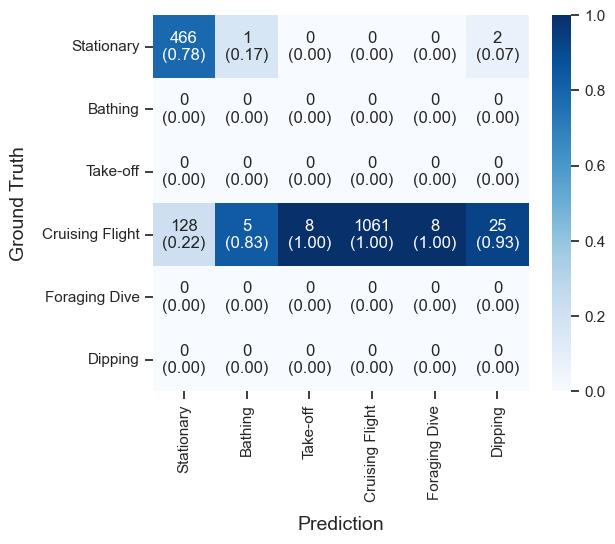

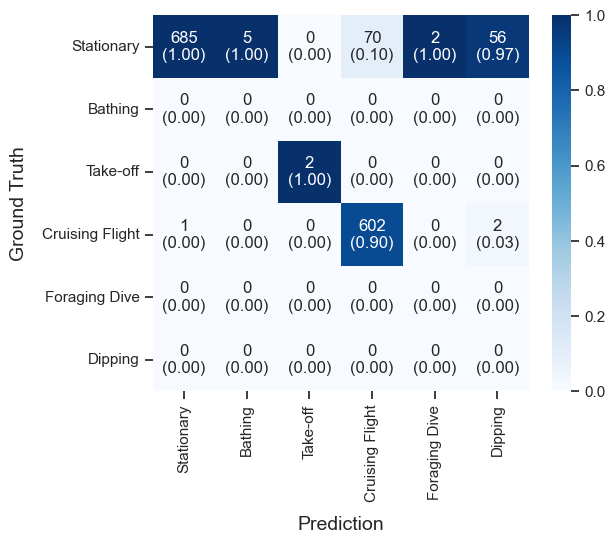

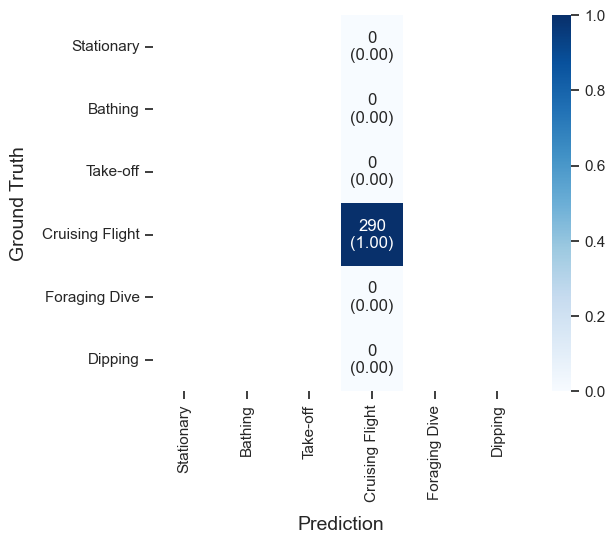

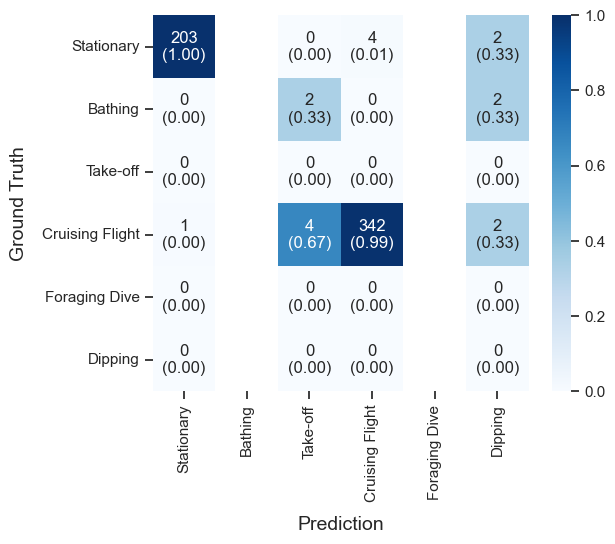

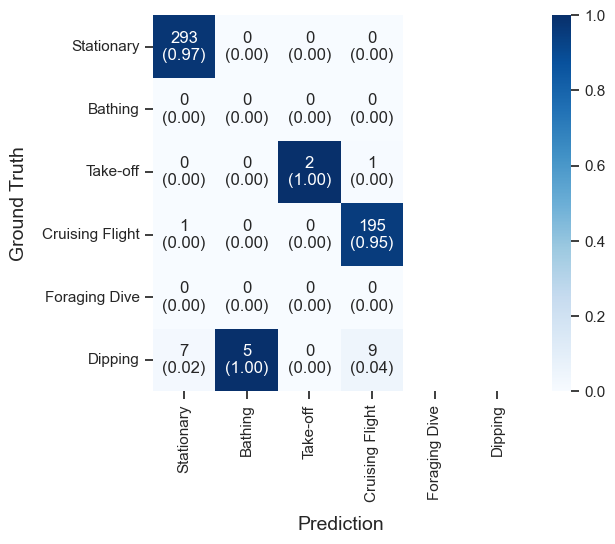

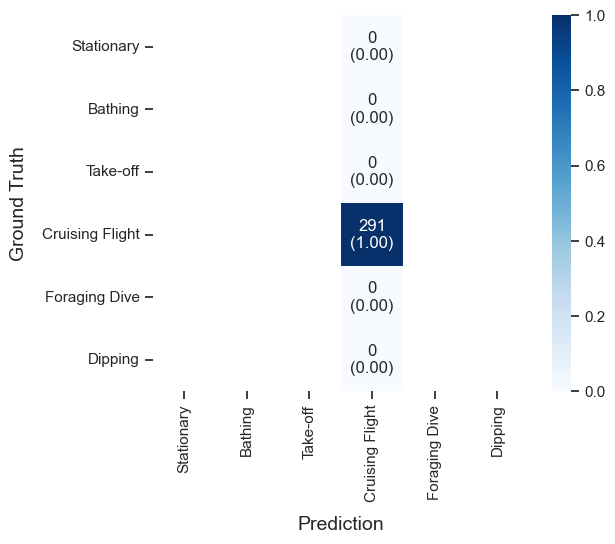

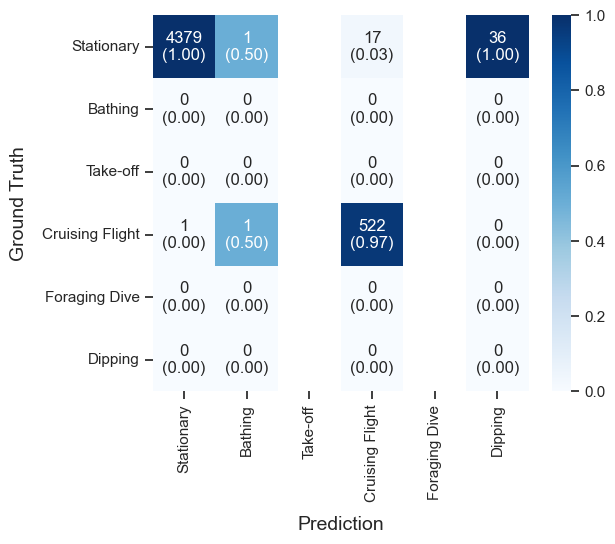

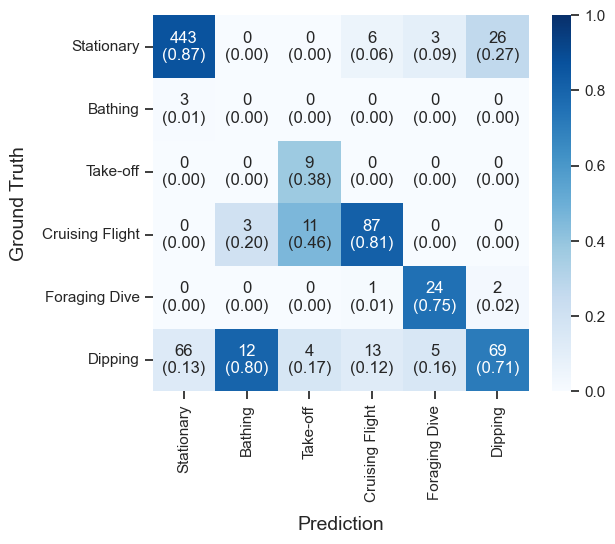

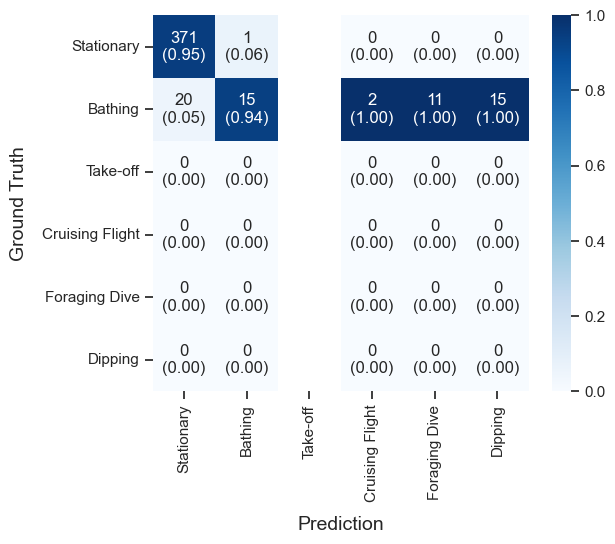

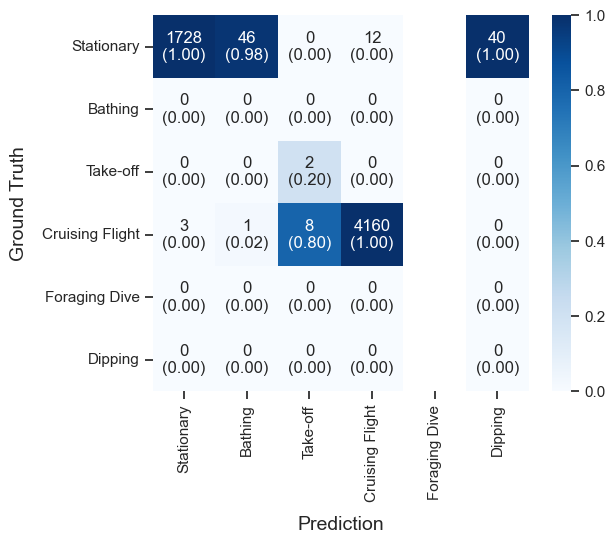

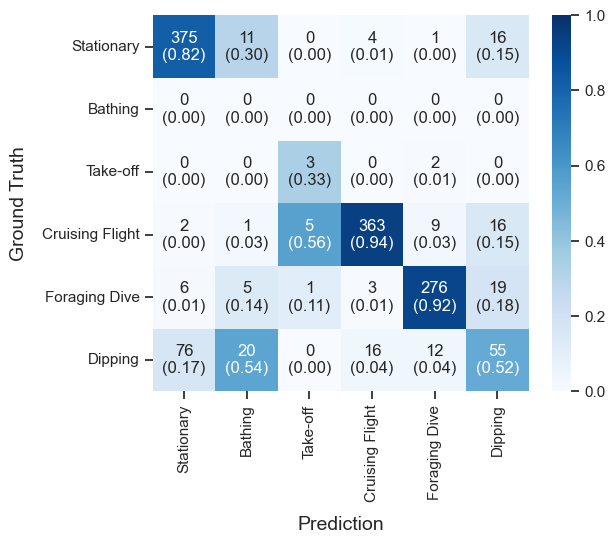

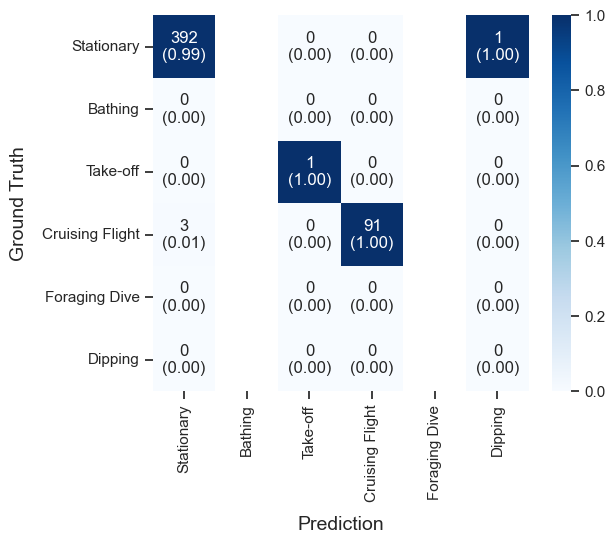

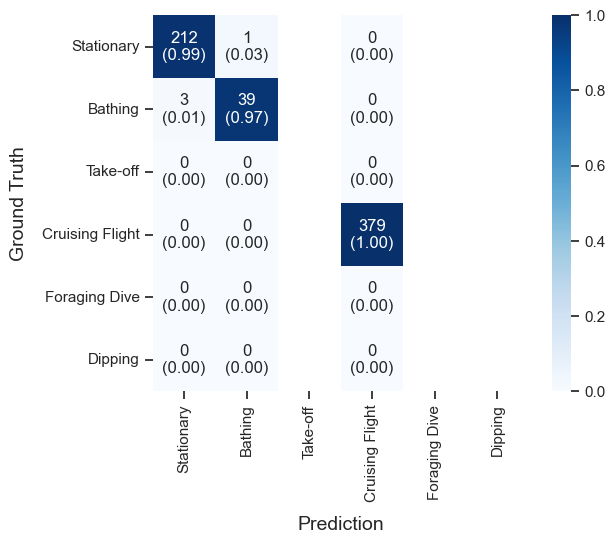

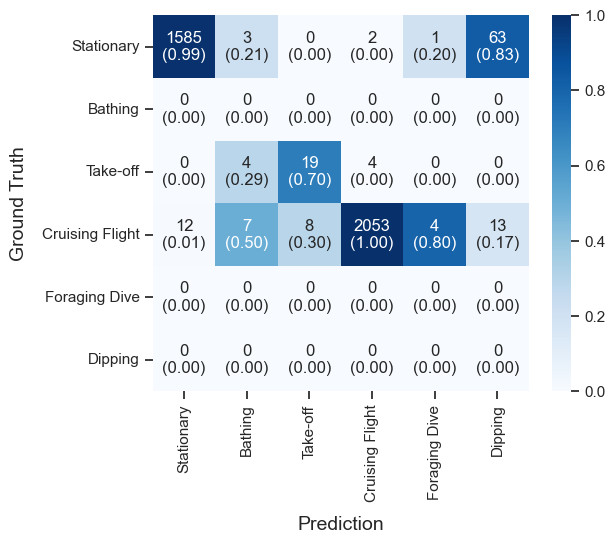

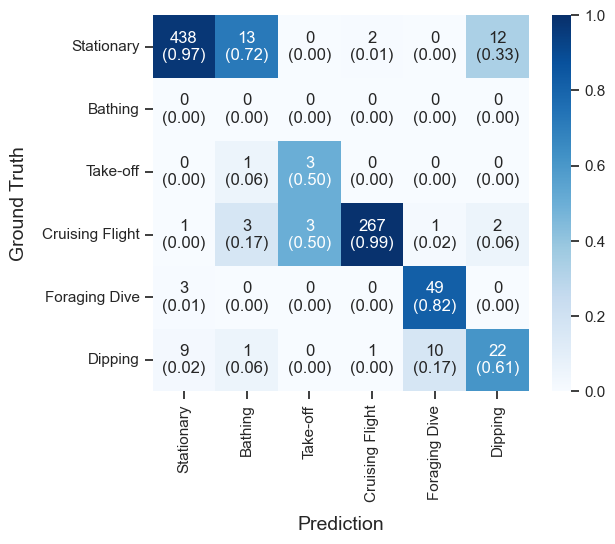

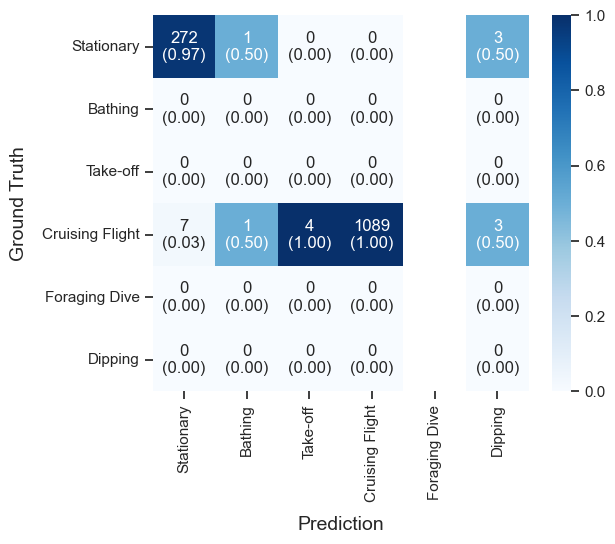

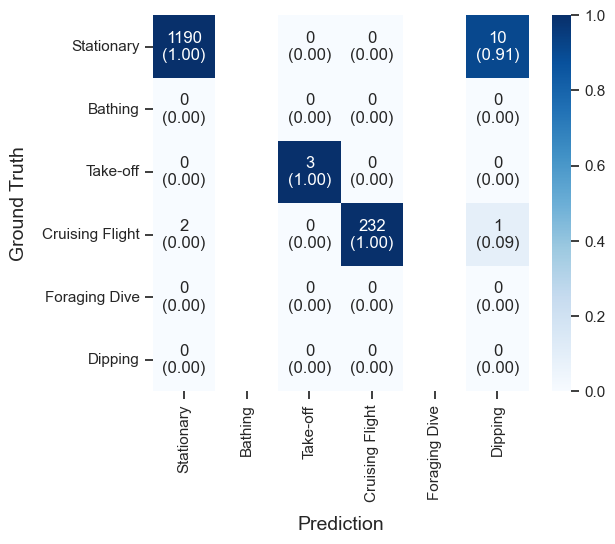

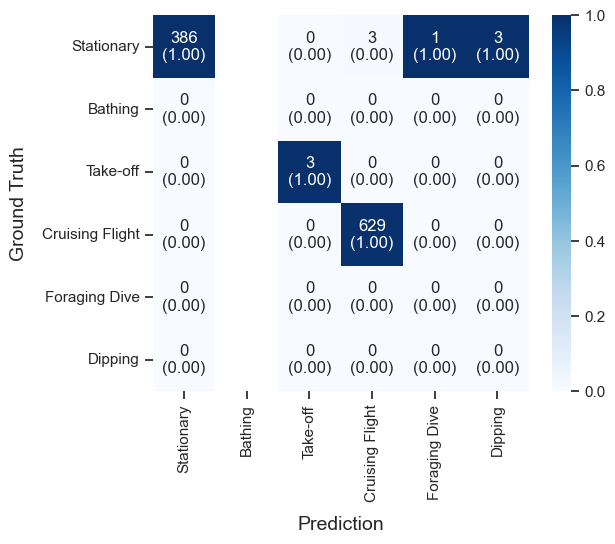

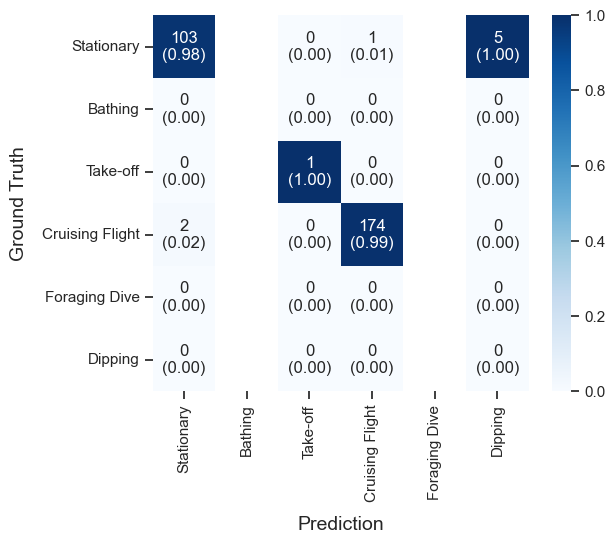

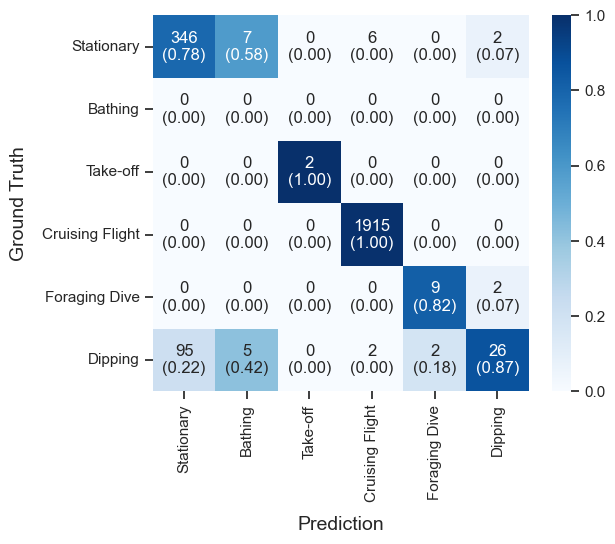

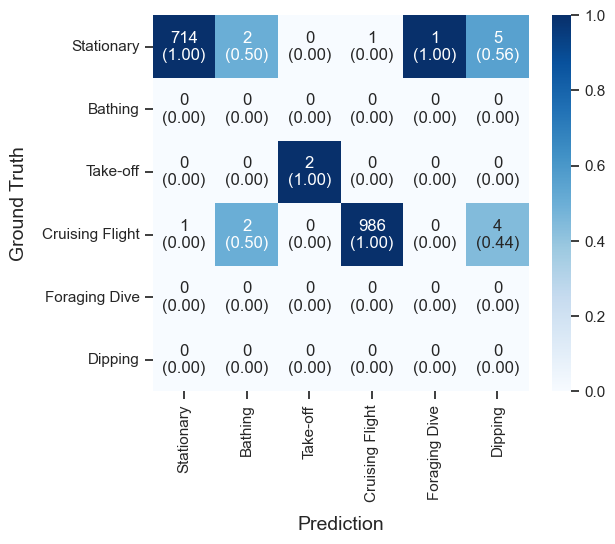

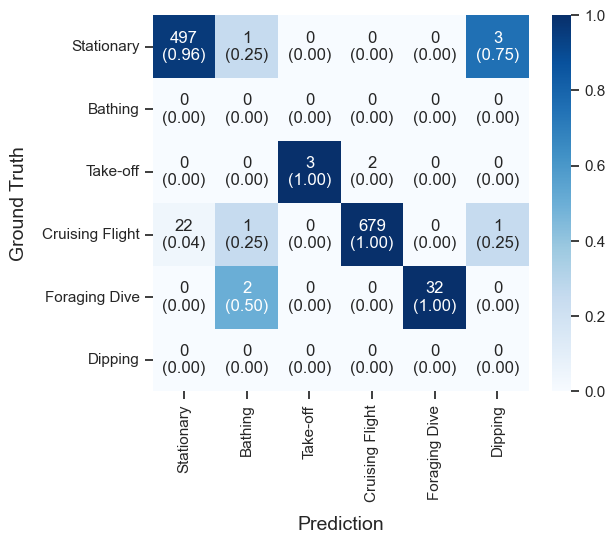

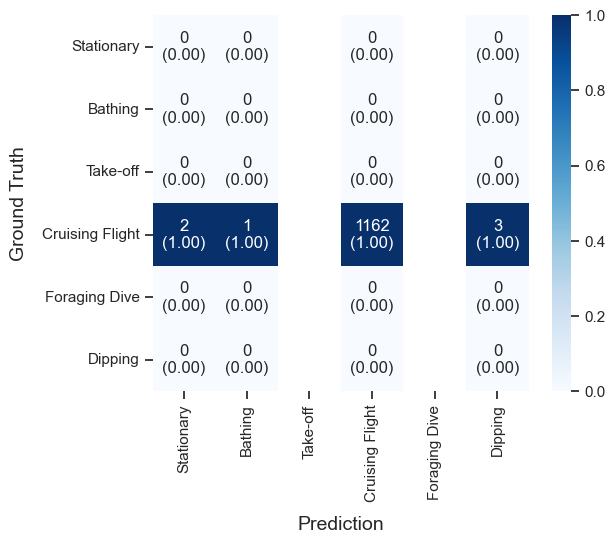

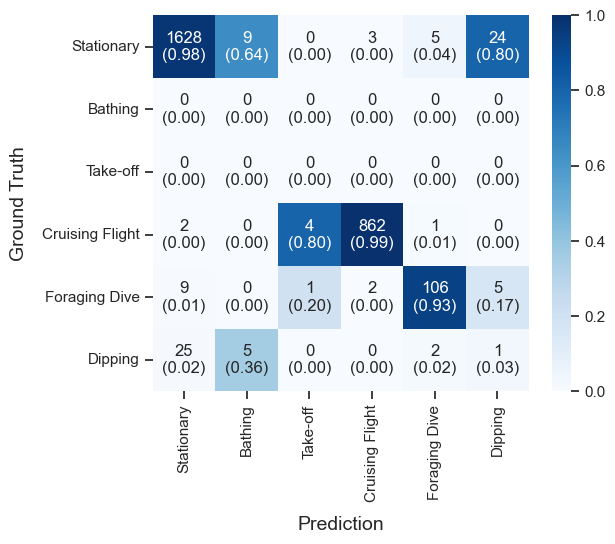

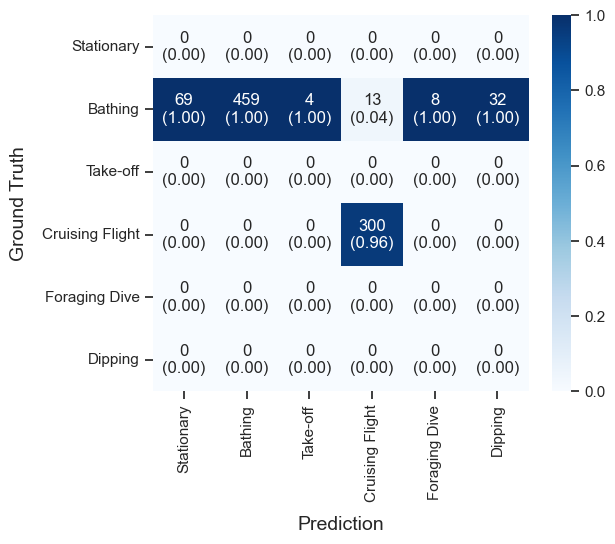

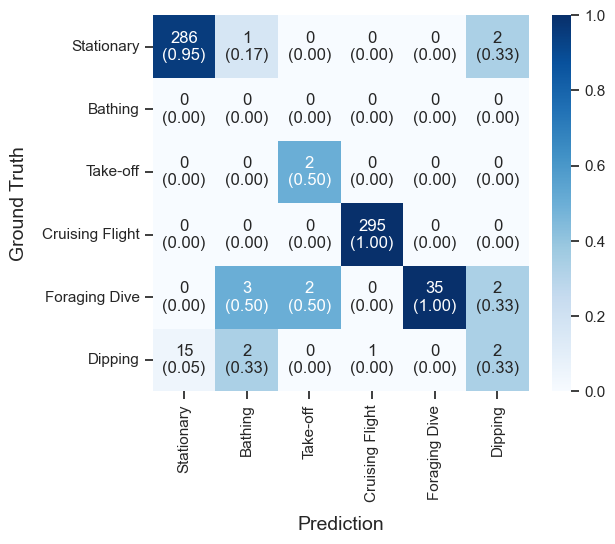

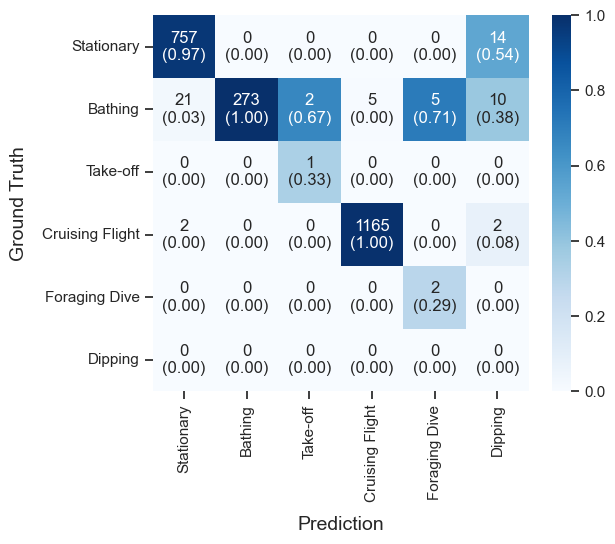

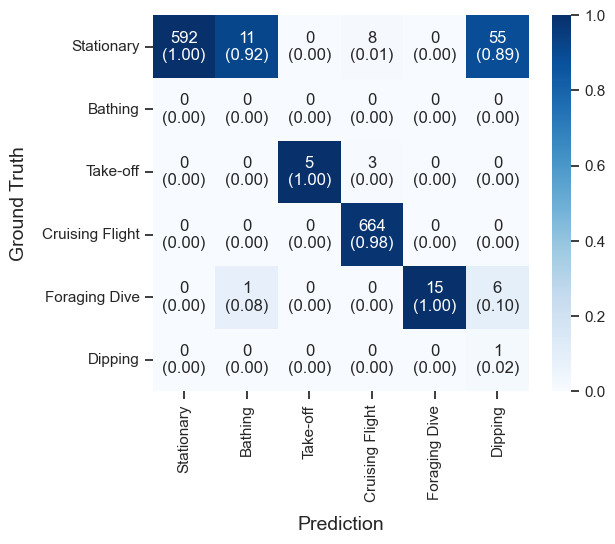

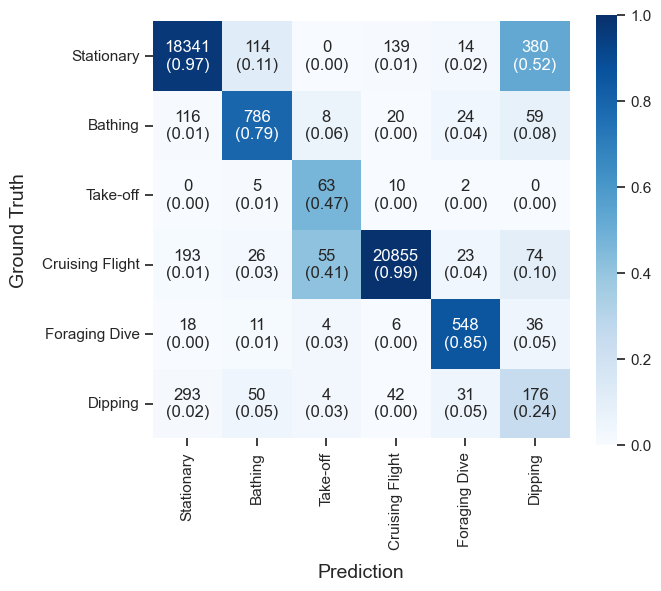

In [25]:
# =============================================================================
# 对每个实验条件和随机种子执行 LOIO-CV 测试
#
# 对应论文第 2.3 节（评估方法）和第 3 节（实验结果）：
#   - 使用训练好的模型在测试集上评估性能
#   - 计算每个测试个体的准确率、精确率、召回率、F1 分数
#   - 汇总所有折的结果，计算宏平均和加权平均 F1
#   - 生成混淆矩阵（图 7）
#
# 测试流程：
#   1. 遍历所有实验条件（condition）和随机种子（seed）
#   2. 对每个 LOIO-CV 折加载对应的最佳模型
#   3. 在测试集上运行推理
#   4. 收集所有折的预测结果
#   5. 生成汇总的性能指标和混淆矩阵
#   6. 保存测试结果
# =============================================================================

# -------------------- 外层循环：遍历实验条件 --------------------
# condition_list 示例：['seed0', 'seed1', ...]
# 每个 condition 对应一个随机种子条件的实验
for c, condition in enumerate(condition_list):
    print("-------------------------------------------------------------")
    print(f"condition: {condition}")

    # -------------------- 中层循环：遍历随机种子 --------------------
    # seed_list 示例：[0, 1, 2] 或 [0] 或 [0,1,2,...,9]
    # 每个 seed 对应一次完整的 LOIO-CV 运行
    for s, seed in enumerate(seed_list):
        print(f"seed: {seed}")

        # --- 步骤 1：初始化结果收集容器 ---
        # 用于收集当前种子下所有 LOIO-CV 折的预测结果
        y_gt_all = []            # y_gt_all：所有测试样本的真实标签
        y_pred_all = []          # y_pred_all：所有测试样本的预测标签
        test_animal_id_all = []  # test_animal_id_all：每个测试样本对应的个体 ID

        # --- 步骤 2：生成配置路径列表 ---
        # generate_test_config_target() 返回：
        #   - config_target：用于 glob 匹配的路径模式
        #   - path_list：匹配到的实际路径列表
        #
        # config_target 示例：
        #   data/model-output/I03/ex-d00/om-50/dcl-sa/seed0/**/config.yaml
        #
        # config_path_list 包含所有 LOIO-CV 折的 config.yaml 路径
        # 每个路径对应一个测试个体
        config_target, path_list = generate_test_config_target(issue, ex, dataset, model_name, condition, seed)
        config_path_list = sorted(glob.glob(config_target))
        print(f"config_target path: {config_target}")
        print(f"N of target models: {len(config_path_list)}")

        # --- 步骤 3：生成结果保存路径 ---
        # generate_results_save_path() 返回：
        #   - results_save_dir：结果保存目录
        #   - f_basename：文件名前缀
        results_save_dir, f_basename = generate_results_save_path(path_list, checkpoints_fname)

        # --- 步骤 4：遍历每个 LOIO-CV 折（测试个体） ---
        for i, config_path in enumerate(config_path_list):

            # --- 步骤 4a：加载测试配置 ---
            # load_and_setup_test_config() 加载 config.yaml 并设置设备
            #
            # 参数：
            #   - config_path：config.yaml 文件路径
            #   - TEST_CUDA_ID：GPU 设备 ID
            #   - checkpoints_fname：模型权重文件名
            #
            # 返回值：
            #   - cfg：加载后的配置对象
            #   - DEVICE：计算设备（GPU 或 CPU）
            cfg, DEVICE = load_and_setup_test_config(config_path, TEST_CUDA_ID, checkpoints_fname)

            # --- 步骤 4b：设置测试环境 ---
            # test_setup() 加载模型权重和测试数据加载器
            #
            # 返回值：
            #   - test_loader：测试数据加载器
            #   - best_model：加载了最佳权重的模型
            #   - optimizer：优化器（用于测试时不需要，但接口保留）
            #   - criterion：损失函数
            test_loader, best_model, optimizer, criterion = test_setup(cfg, config_path, DEVICE)

            # --- 步骤 4c：在测试集上运行评估 ---
            # test2() 执行完整的测试评估
            #
            # 返回值：
            #   - y_gt：真实标签（NumPy 数组）
            #   - y_pred：预测标签（NumPy 数组）
            #   - features：模型提取的特征（用于 t-SNE 可视化，图 3e-h）
            #   - _cm：混淆矩阵（原始矩阵）
            #   - _df_cm：混淆矩阵（DataFrame 格式）
            #   - _fig_cm：混淆矩阵图（Figure 对象）
            (
                y_gt, y_pred, features, _cm, _df_cm, _fig_cm
            ) = test2(best_model, optimizer, criterion, test_loader, DEVICE, cfg)

            # --- 步骤 4d：将 NumPy 数组转为 Python 列表 ---
            # 便于后续 extend 操作
            y_gt_list = y_gt.tolist()
            y_pred_list = y_pred.tolist()

            # --- 步骤 4e：收集该折的预测结果 ---
            # y_gt_all.extend()：将所有折的真实标签汇总
            # y_pred_all.extend()：将所有折的预测标签汇总
            # test_animal_id_all.extend()：记录每个样本对应的测试个体
            #
            # test_animal_id_all 使用列表乘法：
            #   [cfg.dataset.test_animal_id] * len(y_gt_list)
            #   为每个测试样本重复相同的个体 ID
            y_gt_all.extend(y_gt_list)
            y_pred_all.extend(y_pred_list)
            test_animal_id_all.extend([cfg.dataset.test_animal_id]*len(y_gt_list))

        # --- 步骤 5：生成汇总测试结果集 ---
        # 更新 matplotlib 参数为混淆矩阵专用参数
        plt.rcParams.update(confusion_matrix_parameters)

        # generate_test_results_set() 生成：
        #   - df_test_scores_all：测试分数 DataFrame
        #     - 包含每类的 Precision、Recall、F1
        #     - 以及 Macro 和 Weighted 平均
        #   - df_gt_pred_all：真实值-预测值 DataFrame
        #     - 包含 y_gt、y_pred、test_id 三列
        #   - fig_cm：混淆矩阵图（Figure 对象）
        df_test_scores_all, df_gt_pred_all, fig_cm = generate_test_results_set(
            y_gt_all,
            y_pred_all,
            test_animal_id_all,
            cfg
        )

        # --- 步骤 6：保存测试结果集 ---
        save_test_results_set(results_save_dir, f_basename, df_test_scores_all, df_gt_pred_all)

        print("Saved!")

# 打印测试完成信息
print("-------------------")
print("| Test completed. |")
print("-------------------")